# Исследование данных на качество и предобработка

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from scipy.stats import ttest_ind, levene, shapiro, probplot

In [22]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [23]:
df1 = pd.read_csv(r"C:\Users\glebv\Desktop\data\users_ab (2).csv")
df2 = pd.read_csv(r"C:\Users\glebv\Desktop\data\events_ab (2).csv")

In [24]:
df1.head()

,user_id,group,age,city,device,reg_date
0,user_00000,A,39.0,Другой,Android,2022-11-28
1,user_00001,B,33.0,Москва,iOS,2025-02-02
2,user_00002,A,41.0,Новосибирск,iOS,2023-05-11
3,user_00003,B,50.0,Санкт-Петербург,Android,2024-08-03
4,user_00004,A,32.0,NaN,Android,2024-01-22


In [25]:
df2.head()

,user_id,event_dt,event_type,screen_name,button_name,amount,transaction_type
0,user_00000,2025-11-07 18:08:06.488811,login,NaN,NaN,NaN,NaN
1,user_00000,2025-11-07 18:08:53.488811,screen_view,transfers,NaN,NaN,NaN
2,user_00000,2025-11-07 18:09:38.488811,button_click,NaN,transfer,NaN,NaN
3,user_00000,2025-11-07 18:10:13.488811,screen_view,main,NaN,NaN,NaN
4,user_00000,2025-11-07 18:10:32.488811,button_click,NaN,payment,NaN,NaN


In [26]:
#соединил два датасета в один чтобы было проще работать
df = pd.merge(df2, df1, on='user_id', how='left')

In [27]:
nanc = df.isna().sum()
print("КОЛИЧЕСТВО ПРОПУСКОВ ПО СТОЛБЦАМ:")
print(nanc)

КОЛИЧЕСТВО ПРОПУСКОВ ПО СТОЛБЦАМ:
user_id                  0
event_dt                 0
event_type               0
screen_name         204773
button_name         256813
amount              282453
transaction_type    282399
group                    0
age                  10365
city                 16385
device                 491
reg_date                 0
dtype: int64


In [28]:
#удалил дубликаты
dff = df.drop_duplicates()

In [29]:
#удалил непонятные и ненужные столбцы
cols = ['screen_name', 'button_name', 'amount', 'transaction_type']
df = df.drop(columns=cols)

In [30]:
#переводим в формат дата
df['event_dt'] = pd.to_datetime(df['event_dt'])
df['reg_date'] = pd.to_datetime(df['reg_date'])

In [31]:
#для удобства отсортируем
df = df.sort_values(['user_id', 'event_dt']).reset_index(drop=True)

In [32]:
#фильтруем по возрасту из ТЗ
df = df[(df['age'] < 100) & (df['age'] >= 14)]

In [33]:
#приводим в порядок названия строк
df['device'] = df['device'].str.lower()
df['device'] = df['device'].replace({
    'and+e1782roid': 'android',
    'androidd': 'android'})
print(df['device'].unique().tolist())

['android', 'ios', nan]


In [34]:
#последний день заполнен не полностью, так что его удаляем
cd = pd.to_datetime('2025-11-10')
df = df[df['event_dt'] < cd]

In [35]:
print(df['event_dt'].min())
print(df['event_dt'].max())
print(df['reg_date'].min())
print(df['reg_date'].max())

2025-10-27 01:27:06.488811
2025-11-09 23:59:56.488811
2022-11-18 00:00:00
2025-11-17 00:00:00


In [36]:
#удаляем тех кто зарегистрировался после чем совершил какое-то действие(аномалии) это можно увидеть в блоке кода выше
from datetime import datetime
df = df[df['reg_date'] <= datetime(2025, 11, 9)]

In [37]:
#заполняем пропуски в городах
df['city'] = df['city'].fillna('Другой')

In [38]:
#проверка на то, что событие logout не может быть раньше login в рамках одной сессии 
df_lr = df[df['event_type'].isin(['login', 'logout'])].copy()
df_lr = df_lr.sort_values(['user_id', 'event_dt'])
df_lr['has_login_before'] = (
    df_lr['event_type'].eq('login').groupby(df_lr['user_id']).cumsum())

il = df_lr[(df_lr['event_type'] == 'logout') & (df_lr['has_login_before'] == 0)]
print('Количество таких аномалий:', len(il))

Количество таких аномалий: 0


In [39]:
#заполняем пропуски в device путём поиска соседей
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors

dff = df.copy()

cols = ["group", "city"]
encoders = {}

for col in cols:
    le = LabelEncoder()
    dff[col] = le.fit_transform(dff[col].astype(str))
    encoders[col] = le

dff["event_ts"] = pd.to_datetime(dff["event_dt"]).astype(int) / 10**9
dff["reg_ts"] = pd.to_datetime(dff["reg_date"]).astype(int) / 10**9

features = ["event_ts", "group", "age", "city", "reg_ts"]

known = dff[dff["device"].notna()]
unknown = dff[dff["device"].isna()]

X_known = known[features]
X_unknown = unknown[features]

knn = NearestNeighbors(n_neighbors=5)
knn.fit(X_known)

distances, indices = knn.kneighbors(X_unknown)

pred = []

for neigh_ids in indices:
    devices = known.iloc[neigh_ids]["device"]
    pred.append(devices.mode().iloc[0])

dff.loc[dff["device"].isna(), "device"] = pred

for col, le in encoders.items():
    dff[col] = le.inverse_transform(dff[col].astype(int))

dff = dff.drop(columns=["event_ts", "reg_ts"])
df = dff.copy()

In [40]:
dff = df.copy()
dff = dff.sort_values(['user_id', 'event_dt'])
dff['is_login'] = (dff['event_type'] == 'login').astype(int)
dff['session_id'] = dff.groupby('user_id')['is_login'].cumsum()
dff_sess = dff[dff['session_id'] > 0].copy()

dff_sess['session_start'] = dff_sess.groupby(['user_id', 'session_id'])['event_dt'].transform('min')
dff_sess['session_end'] = dff_sess.groupby(['user_id', 'session_id'])['event_dt'].transform('max')

#Считаем продолжительность
dff_sess['duration_seconds'] = (dff_sess['session_end'] - dff_sess['session_start']).dt.total_seconds()

# Фильтруем сессии меньше 1 секунды
dff_filtered = dff_sess[dff_sess['duration_seconds'] > 1].copy()

durations = dff_filtered['duration_seconds']
print(f'Среднее время сессии: {round(np.mean(durations) / 60, 1)} минут')
print(f'Минимальное время сессии: {round(np.min(durations), 1)} секунд')
print(f'Максимальное время сессии: {round(np.max(durations) / 60, 1)} минут')

dff_filtered = dff_filtered.drop(['session_start', 'session_end', 'is_login'], axis=1)
df = dff_filtered.copy()

Среднее время сессии: 7.5 минут
Минимальное время сессии: 1.0 секунд
Максимальное время сессии: 31.2 минут


In [41]:
#итоги чистки
print('ДО ЧИСТКИ:')
print(f'Количество строк: {len(df2)}')
print(f'Количество пользователей: {df2['user_id'].nunique()}')
print(f'Количество дней: 15')
print('')
print('ПОСЛЕ ЧИСТКИ:')
print(f'Количество строк: {len(df)}')
print(f'Количество пользователей: {df['user_id'].nunique()}')
min_date_dt = df['event_dt'].min().floor('D')
max_date_dt = df['event_dt'].max().floor('D')
min_date_str = min_date_dt.strftime('%Y-%m-%d')
max_date_str = max_date_dt.strftime('%Y-%m-%d')
print(f'Данные с {min_date_str} по {max_date_str}')
daysk = (max_date_dt - min_date_dt).days
print(f'Количество дней: {daysk + 1}')
print(f'Города: {df['city'].unique().tolist()}')
print('')
print('ИТОГИ ЧИСТКИ:')
print(f'Удалил {len(df2) - len(df)} строк')
print(f'В процентах: {round((len(df2) - len(df)) / len(df2) * 100, 2)}%')
print(f'Удалил {df2['user_id'].nunique() - df['user_id'].nunique()} пользователей')
pp = round((df2['user_id'].nunique() - df['user_id'].nunique()) / (df2['user_id'].nunique()) * 100, 2)
print(f'В процентах: {pp}%')

ДО ЧИСТКИ:
Количество строк: 334308
Количество пользователей: 5000
Количество дней: 15

ПОСЛЕ ЧИСТКИ:
Количество строк: 316218
Количество пользователей: 4769
Данные с 2025-10-27 по 2025-11-09
Количество дней: 14
Города: ['Другой', 'Москва', 'Новосибирск', 'Санкт-Петербург', 'Екатеринбург', 'Сыктывкар', 'Орел']

ИТОГИ ЧИСТКИ:
Удалил 18090 строк
В процентах: 5.41%
Удалил 231 пользователей
В процентах: 4.62%


# Проведение расчетов и исследований

In [42]:
# Расчет ключевых метрик для А/Б-теста
datal = []
li = df['group'].unique().tolist()

for n in li:
    dff = df[df['group'] == n]
    dff = dff.sort_values(['user_id', 'event_dt'])
    
    dff['is_login'] = (dff['event_type'] == 'login').astype(int)
    dff['session_id'] = dff.groupby('user_id')['is_login'].cumsum()
    dff_sessions = dff[dff['session_id'] > 0].copy()
    #1
    totals = dff['is_login'].sum()
    #2
    totalso = len(dff[~dff['event_type'].isin(['login', 'logout'])])
    totalsom = totalso / totals
    #3
    session_has_tx = (
        dff_sessions.assign(is_tx = (dff_sessions['event_type'] == 'transaction').astype(int))
        .groupby(['user_id', 'session_id'])['is_tx']
        .max()
    )
    conversion = session_has_tx.mean() * 100

    #создаём табличку
    datal.append({
        'Группа': n,
        'Количество сессий': totals,
        'Cреднее количество событий': totalsom,
        'Конверсия в транзакцию': conversion})
dataf = pd.DataFrame(datal)
print(tabulate(dataf, headers='keys', tablefmt='psql', showindex=False))

+----------+---------------------+------------------------------+--------------------------+
| Группа   |   Количество сессий |   Cреднее количество событий |   Конверсия в транзакцию |
|----------+---------------------+------------------------------+--------------------------|
| A        |               14341 |                      7.52263 |                  77.1634 |
| B        |               18832 |                      7.54036 |                  77.8356 |
+----------+---------------------+------------------------------+--------------------------+


In [43]:
#количество различных событий по группам
li = ['A', 'B']
for i in li:
    dff = df[df['group'] == i]
    print('=' * 33)
    print('Группа', i)
    print('=' * 33)
    value_counts = dff['event_type'].value_counts()
    percentage = dff['event_type'].value_counts(normalize=True) * 100
    
    result = pd.DataFrame({
        'Количество': value_counts,
        'Процент': percentage.round(2)
    })
    print(result)

Группа A
              Количество  Процент
event_type                       
screen_view        53915    39.48
button_click       32379    23.71
transaction        21588    15.81
login              14341    10.50
logout             14340    10.50
Группа B
              Количество  Процент
event_type                       
screen_view        71128    39.59
button_click       42293    23.54
transaction        28579    15.91
login              18832    10.48
logout             18823    10.48


In [44]:
# Среднее количество транзакций на пользователя по группам и типам устройств
datal = []
ans = []
dev = ['android', 'ios']
group = ['A', 'B']

for i in group:
    dff = df[df['group'] == i]
    for n in dev:
        dffg = dff[dff['device'] == n]
        count = (dffg['event_type'] == 'transaction').sum()
        sr = round(count / dffg['user_id'].nunique(), 2)
        ans.append(sr)
    datal.append({
        'Группа': i,
        'Android': ans[0],
        'IOS': ans[1]})
    ans.clear()

dataf = pd.DataFrame(datal)
print('Среднее количество транзакций на пользователя по группам и типам устройств')
print(tabulate(dataf, headers='keys', tablefmt='psql', showindex=False))

Среднее количество транзакций на пользователя по группам и типам устройств
+----------+-----------+-------+
| Группа   |   Android |   IOS |
|----------+-----------+-------|
| A        |      9.18 |  8.86 |
| B        |     12.01 | 11.99 |
+----------+-----------+-------+


In [45]:
# Количество уникальных пользователей, совершивших хотя бы одну транзакцию, по городам и группам
datal = []
ans = []
city = ['Москва', 'Санкт-Петербург', 'Новосибирск', 'Екатеринбург', 'Другой', 'Прочие']
group = ['A', 'B']

for i in group:
    dff = df[df['group'] == i]
    for n in city:
        dffg = dff[dff['city'] == n]
        u = dffg[dffg['event_type'] == 'transaction']['user_id'].nunique()
        ans.append(u)
    datal.append({
        'Группа': i,
        'Москва': ans[0],
        'Санкт-Петербург': ans[1],
        'Новосибирск': ans[2],
        'Екатеринбург': ans[3],
        'Другой': ans[4],
        'Всего': sum(ans)})
    ans.clear()

dataf = pd.DataFrame(datal)
print('Количество уникальных пользователей, совершивших хотя бы одну транзакцию, по городам и группам')
print(tabulate(dataf, headers='keys', tablefmt='psql', showindex=False))

Количество уникальных пользователей, совершивших хотя бы одну транзакцию, по городам и группам
+----------+----------+-------------------+---------------+----------------+----------+---------+
| Группа   |   Москва |   Санкт-Петербург |   Новосибирск |   Екатеринбург |   Другой |   Всего |
|----------+----------+-------------------+---------------+----------------+----------+---------|
| A        |      677 |               532 |           349 |            318 |      499 |    2375 |
| B        |      672 |               548 |           379 |            313 |      459 |    2371 |
+----------+----------+-------------------+---------------+----------------+----------+---------+


In [46]:
group = ['A', 'B']
print('Среднее количество просмотров разделов на пользователя:')
for i in group:
    dff = df[df['group'] == i]
    count = (dff['event_type'] == 'screen_view').sum()
    sr = round(count / dff['user_id'].nunique(), 2)
    print(f'{i}: {sr}')

Среднее количество просмотров разделов на пользователя:
A: 22.56
B: 29.9


In [47]:
sessions = df.groupby(['user_id', 'session_id', 'group'])['duration_seconds'].first().reset_index()
mg = sessions.groupby('group')['duration_seconds'].mean()
print('Среднее время проведённое в приложении по группам:')
print(mg)

Среднее время проведённое в приложении по группам:
group
A    294.115152
B    564.611682
Name: duration_seconds, dtype: float64


In [48]:
su = df.groupby(['user_id', 'group'])['session_id'].nunique().reset_index(name='sc')
mg = su.groupby('group')['sc'].mean()
print("Среднее количество сессий на пользователя:")
print(mg)

Среднее количество сессий на пользователя:
group
A    6.000418
B    7.915931
Name: sc, dtype: float64


# Графики

In [49]:
color = '#FF1493'
colors = ['#FF69B4', '#C71585']

In [50]:
plt.style.use('seaborn-v0_8-whitegrid')

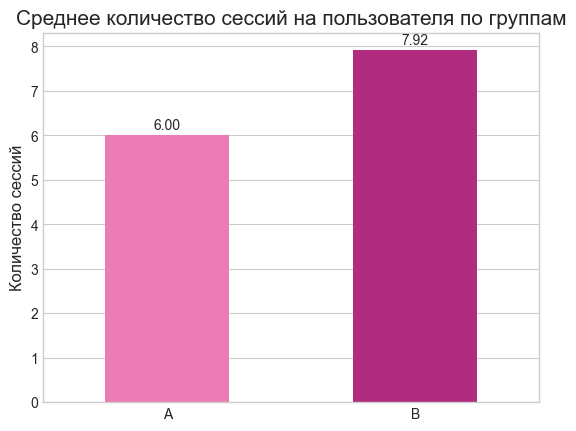

In [51]:
mg = (df.groupby(['user_id', 'group'])['session_id'].nunique().groupby(level=1).mean())
mg = mg.reset_index()

ax = sns.barplot(data=mg, x='group', y='session_id', orient='v', hue='group', palette=colors, width=0.5)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2)
plt.title('Среднее количество сессий на пользователя по группам', fontsize=15)
plt.ylabel('Количество сессий', fontsize=12)
plt.xlabel('')
plt.show()

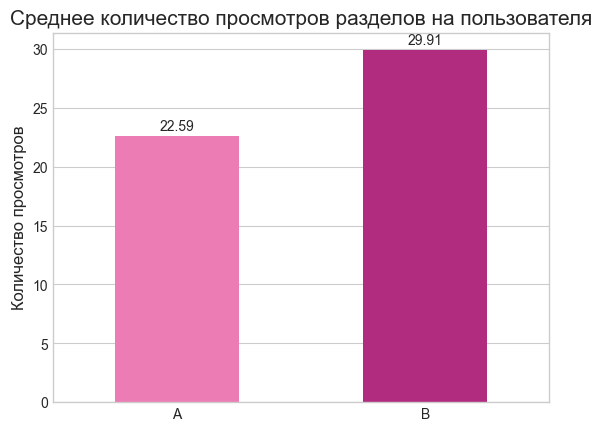

In [52]:
rg = (df[df['event_type'] == 'screen_view']
          .groupby('group')
          .apply(lambda x: round(len(x) / x['user_id'].nunique(), 2), include_groups=False)
          .reset_index(name='count'))

ax = sns.barplot(data=rg, x='group', y='count', orient='v', hue='group', palette=colors, width=0.5)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2)
plt.title('Среднее количество просмотров разделов на пользователя', fontsize=15)
plt.ylabel('Количество просмотров', fontsize=12)
plt.xlabel('')
plt.show()

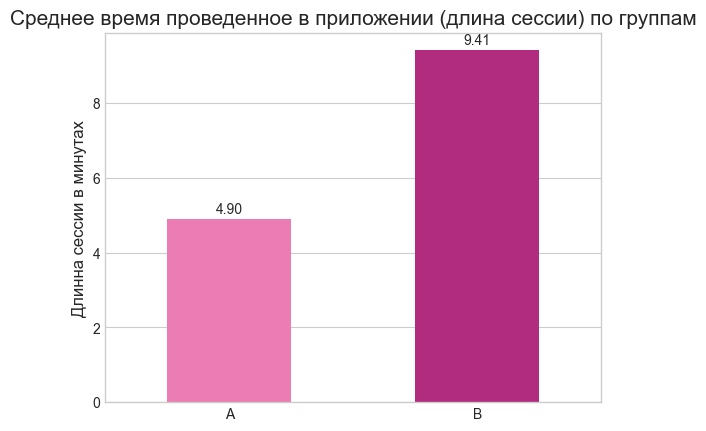

In [53]:
mg = (df.groupby(['user_id', 'session_id', 'group'])['duration_seconds']
      .first()
      .div(60)
      .groupby(level=2)
      .mean()
      .reset_index(name='count'))

ax = sns.barplot(data=mg, x='group', y='count', orient='v', hue='group', palette=colors, width=0.5)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2)
plt.title('Среднее время проведенное в приложении (длина сессии) по группам', fontsize=15)
plt.ylabel('Длинна сессии в минутах', fontsize=12)
plt.xlabel('')
plt.show()

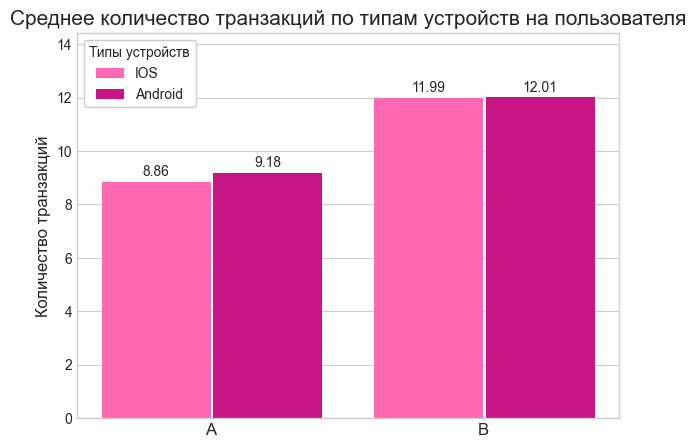

In [54]:
result = (df.groupby(['user_id', 'group', 'device']).apply(lambda x: (x['event_type'] == 'transaction').sum()).reset_index(name='count'))
fd = result.groupby(['group', 'device']).agg(mean=('count', 'mean')).round(3).reset_index()

adf = fd[fd['device'] == 'android'].set_index('group')['mean']
idf = fd[fd['device'] == 'ios'].set_index('group')['mean']

fig, ax = plt.subplots(figsize=(7, 5))
x = range(len(idf))
plt.bar(x, idf, align='center', width=0.4, label='IOS', color=colors[0])
plt.bar([p + 0.41 for p in x], adf, width=0.4, label='Android',color=colors[1])

ax.set_title('Среднее количество транзакций по типам устройств на пользователя', fontsize=15)
ax.set_ylabel('Количество транзакций', fontsize=12)
plt.xticks([p + 0.2 for p in x], idf.index, fontsize=12)
plt.legend(title='Типы устройств', frameon=True, framealpha=1)
plt.grid(axis='x')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2)

ax.set_ylim(0, max(fd['mean']) * 1.2)

plt.show()

# Проверка гипотез

* Среднее количество просмотров разделов на пользователя в группе B больше, чем в группе A.
* Время, проведенное в приложении (длина сессии), в группе B больше, чем в группе A.
* Среднее количество сессий на пользователя в группе B больше, чем в группе A.
* У пользователей с Android из группы B в среднем больше транзакций на одного пользователя, чем у пользователей с Android из группы A.

## Гипотеза 1

In [55]:
svp = (df[df['event_type'] == 'screen_view']
                        .groupby(['user_id', 'group'])
                        .size()
                        .reset_index(name='screen_views'))

group_a1 = svp[svp['group'] == 'A']['screen_views']
group_b1 = svp[svp['group'] == 'B']['screen_views']

print("=== ОСНОВНЫЕ СТАТИСТИКИ ===")
print(f"Группа A: n={len(group_a1)}, среднее={group_a1.mean():.2f}, медиана={group_a1.median():.2f}")
print(f"Группа B: n={len(group_b1)}, среднее={group_b1.mean():.2f}, медиана={group_b1.median():.2f}")

=== ОСНОВНЫЕ СТАТИСТИКИ ===
Группа A: n=2387, среднее=22.59, медиана=21.00
Группа B: n=2378, среднее=29.91, медиана=29.00


In [56]:
stat, p_value = levene(group_b1, group_a1)
print(f"Тест Ливена: p-value = {p_value}; statistics = {stat}")
print(f"Дисперсия группы A: {np.var(group_b1, ddof=1):.3f}")
print(f"Дисперсия группы B: {np.var(group_a1, ddof=1):.3f}")

print('')
if p_value < 0.05:
    print('P-value < 0.05 → Отвергаем Н0. Итог: Дисперсии двух груп различаются')
else:
    print('P-value < 0.05 → НЕ Отвергаем Н0. Итог: Дисперсии двух груп значимо не различаются')

Тест Ливена: p-value = 3.013272164236538e-09; statistics = 35.309185722333396
Дисперсия группы A: 137.561
Дисперсия группы B: 106.959

P-value < 0.05 → Отвергаем Н0. Итог: Дисперсии двух груп различаются


In [57]:
#Односторонний двухвыборочный Т-тест Уэльча для разных дисперсий.
t_stat, p_value = ttest_ind(group_b1, group_a1, alternative='greater', equal_var=False)

print(f"Разница средних: {group_b1.mean() - group_a1.mean()}")
print(f"t-статистика: {t_stat}, p-значение: {p_value}")
print('')
if p_value < 0.05:
    print('Итог: Гипотеза подтвердилась')
else:
    print('Итог: Гипотеза НЕ подтвердилась')

Разница средних: 7.3239202534896926
t-статистика: 22.85863768370805, p-значение: 4.937941309602524e-110

Итог: Гипотеза подтвердилась


## Гипотеза 2

In [58]:
group_a2 = sessions[sessions['group'] == 'A']['duration_seconds']
group_b2 = sessions[sessions['group'] == 'B']['duration_seconds']

print("=== ОСНОВНЫЕ СТАТИСТИКИ ===")
print(f"Группа A: n={len(group_a2)}, среднее={group_a2.mean():.2f}, медиана={group_a2.median():.2f}")
print(f"Группа B: n={len(group_b2)}, среднее={group_b2.mean():.2f}, медиана={group_b2.median():.2f}")

=== ОСНОВНЫЕ СТАТИСТИКИ ===
Группа A: n=14341, среднее=294.12, медиана=208.53
Группа B: n=18832, среднее=564.61, медиана=414.52


In [59]:
stat, p_value = levene(group_b2, group_a2)
print(f"Тест Ливена: p-value = {p_value}; statistics = {stat}")
print(f"Дисперсия группы A: {np.var(group_b2, ddof=1):.3f}")
print(f"Дисперсия группы B: {np.var(group_a2, ddof=1):.3f}")

print('')
if p_value < 0.05:
    print('P-value < 0.05 → Отвергаем Н0. Итог: Дисперсии двух груп различаются')
else:
    print('P-value < 0.05 → НЕ Отвергаем Н0. Итог: Дисперсии двух груп значимо не различаются')

Тест Ливена: p-value = 0.0; statistics = 2931.912679506886
Дисперсия группы A: 244514.530
Дисперсия группы B: 76256.800

P-value < 0.05 → Отвергаем Н0. Итог: Дисперсии двух груп различаются


In [60]:
#Односторонний двухвыборочный Т-тест Уэльча для разных дисперсий.
t_stat, p_value = ttest_ind(group_b2, group_a2, alternative='greater', equal_var=False)

print(f"Разница средних: {group_b2.mean() - group_a2.mean()}")
print(f"t-статистика: {t_stat}, p-значение: {p_value}")
print('')
if p_value < 0.05:
    print('Итог: Гипотеза подтвердилась')
else:
    print('Итог: Гипотеза НЕ подтвердилась')

Разница средних: 270.4965295089015
t-статистика: 63.22948841341473, p-значение: 0.0

Итог: Гипотеза подтвердилась


## Гипотеза 3

In [61]:
group_a3 = su[su['group'] == 'A']['sc']
group_b3 = su[su['group'] == 'B']['sc']

print("=== ОСНОВНЫЕ СТАТИСТИКИ ===")
print(f"Группа A: n={len(group_a3)}, среднее={group_a3.mean():.2f}, медиана={group_a3.median():.2f}")
print(f"Группа B: n={len(group_b3)}, среднее={group_b3.mean():.2f}, медиана={group_b3.median():.2f}")

=== ОСНОВНЫЕ СТАТИСТИКИ ===
Группа A: n=2390, среднее=6.00, медиана=6.00
Группа B: n=2379, среднее=7.92, медиана=8.00


In [62]:
stat, p_value = levene(group_b3, group_a3)
print(f"Тест Ливена: p-value = {p_value}; statistics = {stat}")
print(f"Дисперсия группы A: {np.var(group_b3, ddof=1):.3f}")
print(f"Дисперсия группы B: {np.var(group_a3, ddof=1):.3f}")

print('')
if p_value < 0.05:
    print('P-value < 0.05 → Отвергаем Н0. Итог: Дисперсии двух груп различаются')
else:
    print('P-value < 0.05 → НЕ Отвергаем Н0. Итог: Дисперсии двух груп значимо не различаются')

Тест Ливена: p-value = 6.350850071229106e-08; statistics = 29.346311821125816
Дисперсия группы A: 7.588
Дисперсия группы B: 6.045

P-value < 0.05 → Отвергаем Н0. Итог: Дисперсии двух груп различаются


In [63]:
#Односторонний двухвыборочный Т-тест Уэльча для разных дисперсий.
t_stat, p_value = ttest_ind(group_b3, group_a3, alternative='greater', equal_var=False)

print(f"Разница средних: {group_b3.mean() - group_a3.mean()}")
print(f"t-статистика: {t_stat}, p-значение: {p_value}")
print('')
if p_value < 0.05:
    print('Итог: Гипотеза подтвердилась')
else:
    print('Итог: Гипотеза НЕ подтвердилась')

Разница средних: 1.9155126534302056
t-статистика: 25.329540206840655, p-значение: 4.2305847961526095e-133

Итог: Гипотеза подтвердилась


## Гипотеза 4

In [64]:
resultf = result[result['device'] == 'ios']
group_a4 = resultf[resultf['group'] == 'A']['count']
group_b4 = resultf[resultf['group'] == 'B']['count']

print("=== ОСНОВНЫЕ СТАТИСТИКИ ===")
print(f"Группа A: n={len(group_a4)}, среднее={group_a4.mean():.2f}, медиана={group_a4.median():.2f}")
print(f"Группа B: n={len(group_b4)}, среднее={group_b4.mean():.2f}, медиана={group_b4.median():.2f}")

=== ОСНОВНЫЕ СТАТИСТИКИ ===
Группа A: n=1197, среднее=8.86, медиана=8.00
Группа B: n=1189, среднее=11.99, медиана=11.00


In [65]:
stat, p_value = levene(group_b4, group_a4)
print(f"Тест Ливена: p-value = {p_value}; statistics = {stat}")
print(f"Дисперсия группы A: {np.var(group_b4, ddof=1):.3f}")
print(f"Дисперсия группы B: {np.var(group_a4, ddof=1):.3f}")

print('')
if p_value < 0.05:
    print('P-value < 0.05 → Отвергаем Н0. Итог: Дисперсии двух груп различаются')
else:
    print('P-value < 0.05 → НЕ Отвергаем Н0. Итог: Дисперсии двух груп значимо не различаются')

Тест Ливена: p-value = 7.273056007315114e-05; statistics = 15.793838260533425
Дисперсия группы A: 28.810
Дисперсия группы B: 22.898

P-value < 0.05 → Отвергаем Н0. Итог: Дисперсии двух груп различаются


In [66]:
t_stat, p_value = ttest_ind(group_b4, group_a4, alternative='greater', equal_var=False)

print(f"Разница средних: {group_b4.mean() - group_a4.mean()}")
print(f"t-статистика: {t_stat}, p-значение: {p_value}")
print('')
if p_value < 0.05:
    print('Итог: Гипотеза подтвердилась')
else:
    print('Итог: Гипотеза НЕ подтвердилась')

Разница средних: 3.1352933778235883
t-статистика: 15.056900566524334, p-значение: 2.7814279649852314e-49

Итог: Гипотеза подтвердилась


# Регрессионное моделирование

In [67]:
data = pd.read_csv(r"C:\Users\glebv\Desktop\data\visits_daily (2).csv")

In [68]:
data.head(10)

,Дата события,visits,holiday_flag
0,2025-05-21,11461,1
1,2025-05-22,9503,0
2,2025-05-23,14367,0
3,2025-05-24,9185,1
4,2025-05-25,9098,1
5,2025-05-26,9645,0
6,2025-05-27,9272,0
7,2025-05-28,11381,0
8,2025-05-29,10750,0
9,2025-05-30,13149,0


In [69]:
data = data.rename(columns={data.columns[0]: 'date'})

In [70]:
data['date'] = pd.to_datetime(data['date'])

In [71]:
data = data.sort_values('date').reset_index(drop=True)

In [72]:
data['day_of_week'] = data['date'].dt.day_name()

In [73]:
data['month'] = data['date'].dt.month_name()

In [74]:
data['is_weekend'] = (data['date'].dt.day_name().isin(['Saturday', 'Sunday'])).astype(int)

In [75]:
data["visits_lag1"] = data["visits"].shift(1)
data["visits_lag7"] = data["visits"].shift(7)

In [76]:
data["day_of_week_num"] = data["date"].dt.weekday

In [77]:
data = data.sort_values("date")

In [78]:
data = data.dropna()

In [79]:
#фильтруем по IQR
Q1 = data['visits'].quantile(0.25)  # 25-й процентиль
Q3 = data['visits'].quantile(0.75)  # 75-й процентиль
IQR = Q3 - Q1                       # Межквартильный размах

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# Фильтруем данные, удаляя выбросы
data = data[data['visits'] <= upper_bound]

# Вывод результатов
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Верхняя граница: {upper_bound}")

Q1: 9829.25, Q3: 12947.25, IQR: 3118.0
Верхняя граница: 17624.25


In [80]:
for i in range(4):
    dfg = data.groupby(data.iloc[:, 2 + i])['visits'].mean()
    print(dfg)
    print('='*33)

holiday_flag
0    12280.663793
1     9248.703704
Name: visits, dtype: float64
day_of_week
Friday       12268.160000
Monday       12464.695652
Saturday      8998.480000
Sunday        8960.640000
Thursday     12297.400000
Tuesday      12182.391304
Wednesday    12249.458333
Name: visits, dtype: float64
month
August       11277.741935
July         10853.586207
June         10660.466667
May          10966.750000
November     11608.941176
October      12131.387097
September    11518.464286
Name: visits, dtype: float64
is_weekend
0    12291.741667
1     8979.560000
Name: visits, dtype: float64


In [81]:
#сама моделька
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import matplotlib.pyplot as plt
import statsmodels.api as sm

X = data[["is_weekend", "holiday_flag", "day_of_week_num", "visits_lag1", "visits_lag7"]]
y = data["visits"]

split_index = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

data['predicted_visits'] = None

data.loc[X_test.index, 'predicted_visits'] = y_pred

In [82]:
#метрики
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("MAPE:", mape)
print("RMSE:", rmse)
print(f"Модель ошибается в среднем на {mae:.0f} посещений, что составляет {mape:.1f}% от среднего значения")

MAE: 1135.8739586374961
MAPE: 9.326434822292361
RMSE: 1377.9018456502617
Модель ошибается в среднем на 1136 посещений, что составляет 9.3% от среднего значения


In [83]:
#p-value
print('Гипотеза: Количество посещений зависит от того был выходной или будний день')
X_sm = sm.add_constant(data[["is_weekend"]])
ols = sm.OLS(y, X_sm).fit()
p_value = ols.pvalues["is_weekend"]
print("p-value:", p_value)
if p_value < 0.05:
    print('Итог: Гипотеза подтвердилась')
else:
    print('Итог: Гипотеза НЕ подтвердилась')

Гипотеза: Количество посещений зависит от того был выходной или будний день
p-value: 3.1462292426166223e-35
Итог: Гипотеза подтвердилась


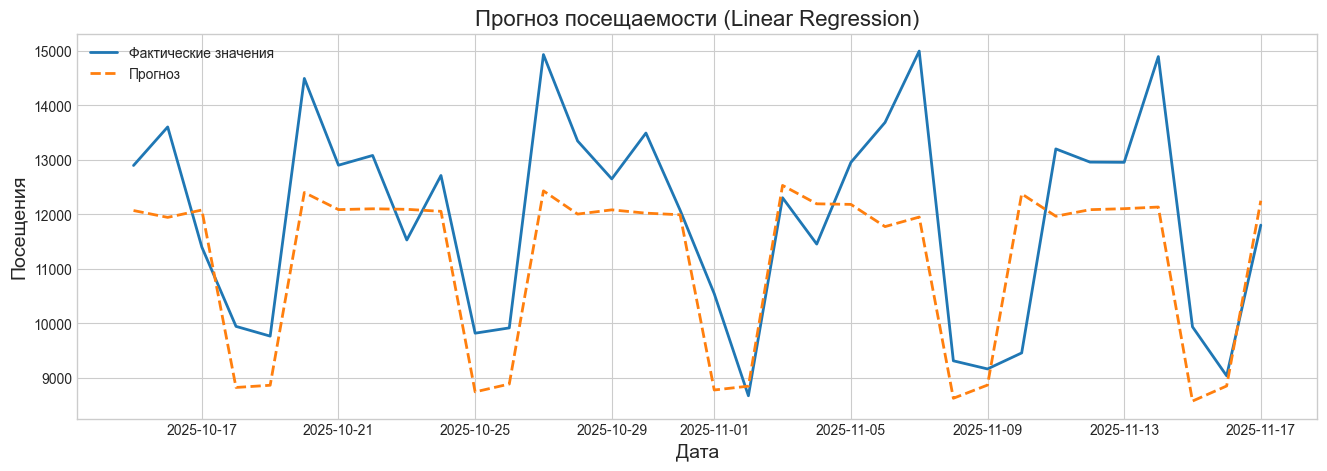

In [84]:
plt.figure(figsize=(16, 5))
plt.plot(data["date"].iloc[split_index:], y_test.values, label="Фактические значения", linewidth=2)
plt.plot(data["date"].iloc[split_index:], y_pred, label="Прогноз", linestyle="--", linewidth=2)
plt.legend()
plt.title("Прогноз посещаемости (Linear Regression)", fontsize=16)
plt.xlabel("Дата", fontsize=14)
plt.ylabel("Посещения", fontsize=14)
plt.grid(True)
plt.show()